### Adaptive RAG

Adaptive RAG (Retrieval-Augmented Generation) is a framework that dynamically adjusts its strategy for handling queries based on their complexity. It's like having a smart assistant that knows when to dig deep for information and when to provide a simple answer. Instead of using a single, rigid approach, Adaptive RAG chooses the most appropriate retrieval method for each query, balancing speed and accuracy.

Adaptive RAG is a strategy for RAG that unites (1) query analysis with (2) active/self-corrective RAG.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

c:\Users\bhanu\Desktop\AI Agents course\AI-Agents-Learning\AgenticAIWorkspace\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [28]:
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
from langchain_community.tools.tavily_search import TavilySearchResults
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END

In [13]:
client = Client()

In [22]:
web_search_tool=TavilySearchResults(k=3)

C:\Users\bhanu\AppData\Local\Temp\ipykernel_10080\2495305207.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool=TavilySearchResults(k=3)


In [3]:
urls=[
"https://docs.langchain.com/oss/python/langgraph/overview/",
"https://docs.langchain.com/oss/python/langgraph/workflows-agents/",
"https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api"
]
docs=[WebBaseLoader(url).load() for url in urls]
doc_list=[doc for sublist in docs for doc in sublist]
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
doc_splits=text_splitter.split_documents(doc_list)
vectorstore=FAISS.from_documents(documents=doc_splits,embedding=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2"))

retriever=vectorstore.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2309.02it/s]


In [4]:
from typing import Annotated, Sequence,List,Literal
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
from langchain_groq import ChatGroq
from pydantic import BaseModel,Field

In [7]:
#Data model
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource"""
    datasource: Literal["vectorstore","web_search"]=Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore."
    )

llm=ChatGroq(model="openai/gpt-oss-20b")
structured_llm_router=llm.with_structured_output(RouteQuery)

In [ ]:
#prompt
system="""You are an expert at routing a user question to a vectorstore or websearch. The vectorstore contains related to agents, 
agent worflows, graph api and their implementation using langgraph. Use the vectorstore for questions on these topics. Otherwise use 
web search."""

route_prompt=ChatPromptTemplate.from_messages([
    ("system", system),
    ("human", "{question}")
])

question_router= route_prompt | structured_llm_router

In [11]:
### Retrieval grader
class GradeDocuments(BaseModel):
    """Binary score for relevant check on retrieved documents."""

    binary_score:str=Field(description="Documents are relevant to the question, 'yes' or 'no'")

structured_llm_grader=llm.with_structured_output(GradeDocuments)

system="""You are a grader assessing relevance of a retrieved document to a user question. \n
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    It does not need to be a stringent test. The goa is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
    """

grade_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","Retrieved document: \n\n {document} \n\n User question: {question}")
    ]
)

retrieval_grader=grade_prompt | structured_llm_grader
question="What are ai agents?"
docs=retriever.invoke(question)
docs_txt=docs[1].page_content
print(retrieval_grader.invoke({"question":question,"document":docs_txt}))

binary_score='yes'


In [15]:
#Prompt
prompt=client.pull_prompt("rlm/rag-prompt",dangerously_pull_public_prompt=True)

#Post processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

#Chain
rag_chain=prompt | llm | StrOutputParser()
generation=rag_chain.invoke({"context":docs,"question":question})
print(generation)

AI agents are software systems that use large language models (LLMs) to perform tasks by calling tools and making decisions in a continuous feedback loop. They are more autonomous than simple workflows, able to choose which tools to use and how to solve unpredictable problems while following defined guidelines. Agents can persist across failures, maintain short‑ and long‑term memory, and support human oversight for complex, long‑running tasks.


In [18]:
### Hallucination grader
class GradeHallucination(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score:str=Field(description="Answer is grounded in the facts, 'yes' or 'no'")

structured_llm_grader=llm.with_structured_output(GradeHallucination)

system="""You are a grader assessing whether an LLM generation is gorunded in / supported by a set of retrieved facts. \n
Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

hallucination_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","Set of facts: \n\n {documents} \n\n LLM generation: {generation}")
    ]
)

hallucination_grader=hallucination_prompt | structured_llm_grader
print(hallucination_grader.invoke({"documents":docs,"generation":generation}))

binary_score='yes'


In [19]:
### Answer grader
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score:str=Field(description="Answer answer addresses question, 'yes' or 'no'")

structured_llm_grader=llm.with_structured_output(GradeAnswer)

system="""You are a grader assessing whether an answer addresses/ resolves a question. \n
Give a binary score 'yes' or 'no'. 'Yes' means that the answer addresses/ resolves the question."""

answer_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","Set of facts: \n\n {question} \n\n LLM generation: {generation}")
    ]
)

answer_grader=answer_prompt | structured_llm_grader
print(answer_grader.invoke({"question":question,"generation":generation}))

binary_score='yes'


In [20]:
#Question rewriter

system="""You are a question rewriter that converts an input question to a better version that is optimized \n
for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""

re_write_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human", "Here is the initial question: \n\n {question} \n\n Formulate an improved question.")
    ]
)

question_rewriter= re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question":question})

'What are AI agents, and how are they defined, classified, and applied within modern artificial intelligence systems?'

In [25]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
    question: question
    generation: LLM generation
    documents: list of documents
    """
    question:str
    generation:str
    documents:List[str]

In [37]:
def retrieve(state):
    """Retrieve documents
    
    Args:
        state (dict): New key added to state, documents, that contains retrieved documents    
    
    Returns:
        state(dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question=state["question"]

    #Retrieval
    documents=retriever.invoke(question)
    return {"documents":documents, "question":question}

def generate(state):
    """
    Generate answer
    
    Args:
       state (dict): The curent graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """

    print("--GENERATE---")
    question=state["question"]
    documents=state["documents"]

    #RAG generation
    generation = rag_chain.invoke({"context":documents,"question":question})
    return {"documents":documents,"question":question,"generation":generation}

def grade_documents(state):
    """
    Determine whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state
    
    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """
    print("---CHECK DOCUMENT RELAVANCE TO QUESTION---")
    question=state["question"]
    documents=state["documents"]

    #Score each doc
    filtered_docs=[]
    for d in documents:
        score = retrieval_grader.invoke(
            {"question":question,"document":d.page_content}
        )
        grade=score.binary_score
        if grade=="yes":
            print("--GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEAVANT---")
            continue
    return {"documents":filtered_docs,"question":question}

def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
       state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question=state["question"]
    documents=state["documents"]

    #Re-write question
    better_question=question_rewriter.invoke({"question":question})
    return {"documents":documents,"question":better_question}

def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state    
    
    Returns:
        state (dict): Updates documents key with appended web results    
    """
    print("---WEB SEARCH---")
    question=state["question"]

    #Web search
    docs=web_search_tool.invoke({"query":question})
    web_results="\n".join([d["content"] for d in docs])
    web_results=Document(page_content=web_results)

    return {"documents":web_results, "question":question}

def route_question(state):
    """
    Route question to web search or RAG.

    Args:
       state (dict): The current graph state

    Returns:
        str: Next node to call
    """
    print("---ROUTE QUESTION---")
    question=state["question"]
    source=question_router.invoke({"question":question})
    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"

def decide_to_generate(state):
    """
    Determine whether to generate an answer, or re-generate a question.
    
    Args:
        state(dict): The current graph state
    
    Returns:
        str: Binary decision for next node to call
    """

    print("--ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents=state["documents"]

    if not filtered_documents:
        print("---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---")
        return "transform_query"
    else:
        print("---DECISION: GENERATE---")
        return "generate"

def grade_generation_v_documents_and_question(state):
    """Determines whether the generation is grounded in the document and answers question.
    
    Args:
       state (dict): The current graph state

    Returns:
        ste: Decision for next node to call
    """

    print("--CHECK HALLUCINATIONS---")
    question=state["question"]
    documents=state["documents"]
    generation=state["generation"]

    score=hallucination_grader.invoke({"documents":documents,"generation":generation})
    grade=score.binary_score

    if grade=="yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        print("--GRADE GENERATION vs QUESTION---")
        score=answer_grader.invoke({"question":question,"generation":generation})
        grade=score.binary_score
        if grade=="yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION, RE-TRY--")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [38]:
workflow=StateGraph(GraphState)

#Define the nodes
workflow.add_node("retrieve",retrieve)
workflow.add_node("grade_documents",grade_documents)
workflow.add_node("transform_query",transform_query)
workflow.add_node("web_search",web_search)
workflow.add_node("generate",generate)

#Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search":"web_search",
        "vectorstore":"retrieve"
    }
)

workflow.add_edge("web_search","generate")
workflow.add_edge("retrieve","grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query":"transform_query",
        "generate":"generate"
    }
)
workflow.add_edge("transform_query","retrieve")

workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not useful":"transform_query",
        "not supported":"generate",
        "useful":END
    }
)

app=workflow.compile()

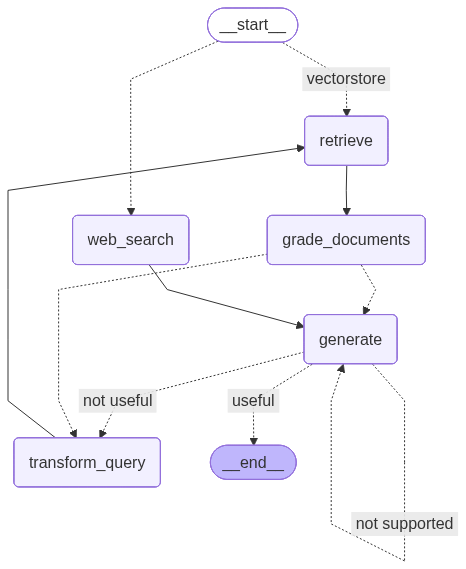

In [39]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [40]:
app.invoke({"question":"What is machine learning?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
--GENERATE---
--CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
--GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is machine learning?',
 'generation': 'Machine learning is a subfield of artificial intelligence that trains models to learn patterns from data and make predictions or generate content without being explicitly programmed. It relies on statistical algorithms and optimisation techniques, and is typically divided into supervised, unsupervised, reinforcement and generative (AI) approaches. The goal is to generalise from training data so the model can infer correct outputs on unseen data.',
 'documents': Document(metadata={}, page_content='Glossary\n\n   Glossary\n   v\n   t\n   e\n\nMachine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from pre-trained data and generalize to unseen data, and thus perform tasks "Task (computing)") without being explicitly programmed.( Advances in the field of deep learning have allowed neural networks "Neural network (machine learning)"), a cl

In [41]:
app.invoke({"question":"What are ai agents?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELAVANCE TO QUESTION---
--GRADE: DOCUMENT RELEVANT---
--GRADE: DOCUMENT RELEVANT---
--GRADE: DOCUMENT RELEVANT---
--GRADE: DOCUMENT RELEVANT---
--ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
--GENERATE---
--CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
--GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What are ai agents?',
 'generation': 'AI agents are autonomous systems—typically powered by large language models—that can perform actions using a set of tools and decide how to solve unpredictable problems. They run in continuous feedback loops, allowing them to adapt their behavior and tool usage over time. In LangGraph, agents are modeled as graph‑based workflows that provide durable execution, stateful memory, and human‑in‑the‑loop oversight.',
 'documents': [Document(id='76c12233-cd81-456b-a24e-09be9d15e8d3', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/graph-api#map-reduce-and-the-send-api', 'title': 'Graph API overview - Docs by LangChain', 'language': 'en'}, page_content='At its core, LangGraph models agent workflows as graphs. You define the behavior of your agents using three key components:'),
  Document(id='a3919c82-5832-420b-a2e7-213fe5146ca0', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/workflows-agents/', 'ti

Failed to refresh cache entry rlm/rag-prompt: Connection error caused failure to GET /commits/rlm/rag-prompt/latest in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /commits/rlm/rag-prompt/latest (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langchain.com\', port=443): Failed to resolve \'api.smith.langchain.com\' ([Errno 11001] getaddrinfo failed)"))'))
Content-Length: None
API Key: lsv2_********************************************9e
Failed to refresh cache entry rlm/rag-prompt: Connection error caused failure to GET /commits/rlm/rag-prompt/latest in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /commits/rlm/rag-prompt/latest (Caused by NameResolutionError("HTTPSConnection(host=\'api.smith.langcha